In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

from rich import print

from surfh.Preprocessing import model_creation
from surfh.ToolsDir import reconstruction
from surfh.Vizualisation import cube_vizualisation
from surfh.ToolsDir.fits_toolbox import save_numpy_to_fits

import click
import logging as log


In [ ]:
fusion_dir = '/home/nmonnier/Data/JWST/NGC_7023/Fusion/'
npix = 125
hyper_parameter = 1.
niter = 5
n_templates = 4
scale_data = True
method = 'lcg'
filtered_data = False
verbose = True

print(f'Options selected are : ') 
print(f'\t fusion_dir = {fusion_dir}')
print(f'\t npix = {npix}')
print(f'\t hyper_parameter = {hyper_parameter}')
print(f'\t niter = {niter}')
print(f'\t nTemplates = {n_templates}')
print(f'\t scale_data = {scale_data}')
print(f'\t method = {method}')
print(f'\t filtered_data = {filtered_data}')
print(f'\t verbose = {verbose}')

if verbose:
    log.basicConfig(format="%(levelname)s: %(message)s", level=log.INFO)

list_chan = ['1a', '1b', '1c', '2a', '2b', '2c', '3a', '3b', '3c', '4a', '4b']
imshape = (npix, npix)

log.info('Initialize basic path parameters')
step = 0.1  # arcsec
paths, step_angle = model_creation.initialize_parameters(fusion_dir, step, filtered_data)


log.info('Load simulation data')
wavel_axis, templates, sotf = model_creation.load_simulation_data(paths, list_chan)


log.info('Load MRS data')
data_dict = model_creation.load_data(list_chan, paths["save_filter_corrected_dir"])


log.info('Cerate intruments and spectro models')
instruments = model_creation.create_instruments(data_dict, list_chan) # Warning Here : Rotation is set as -rotation_angle
MRSModel = model_creation.create_model(sotf, templates, wavel_axis, instruments, step_angle, data_dict, imshape)

data = list()
for chan in list_chan:
    data.append(np.array(data_dict['data'][chan]).ravel())
ndata = np.concatenate(data)

if scale_data:
    log.info('Data scaling enable')
    ndata = MRSModel.real_data_janskySR_to_jansky(ndata)


print(f"ndata shape: {ndata.shape}")

list_raw_data = MRSModel.get_list_of_data(ndata)
print(f"List of data length: {len(list_raw_data)}")

corrected_maps = np.load('/home/nmonnier/Data/JWST/NGC_7023/Fusion/Results/lcg_MC_11_MO_4_Temp_14_nit_150_mu_5.00e+06_SD_True/res_x.npy')
corrected_data = MRSModel.forward(corrected_maps)
list_corrected_data = MRSModel.get_list_of_data(corrected_data)
print(f"List of corrected data length: {len(list_corrected_data)}")

log.info(f'Start {method} algorithm')


Options selected are :

fusion_dir = /home/nmonnier/Data/JWST/NGC_7023/Fusion/

npix = 125

hyper_parameter = 1.0

niter = 5

...

Channel 3b corrected data shape: (4, 16, 892, 26)

Channel 3c corrected data shape: (4, 16, 1028, 26)

Channel 4a corrected data shape: (4, 12, 542, 33)

Channel 4b corrected data shape: (4, 12, 632, 33)

INFO: Start lcg algorithm


Data path is  /home/nmonnier/Data/JWST/NGC_7023/Fusion/Filtered_slices/

INFO: Load MRS data


Order of channels loading :

Loading data for channel 1a from file ch1a_00001_corrected_filtered.fits

Loading data for channel 1a from file ch1a_00002_corrected_filtered.fits

...

Loading data for channel 4a from file ch4a_00004_corrected_filtered.fits

Loading data for channel 4b from file ch4b_00001_corrected_filtered.fits

Loading data for channel 4b from file ch4b_00002_corrected_filtered.fits

Loading data for channel 4b from file ch4b_00003_corrected_filtered.fits

Loading data for channel 4b from file ch4b_00004_corrected_filtered.fits

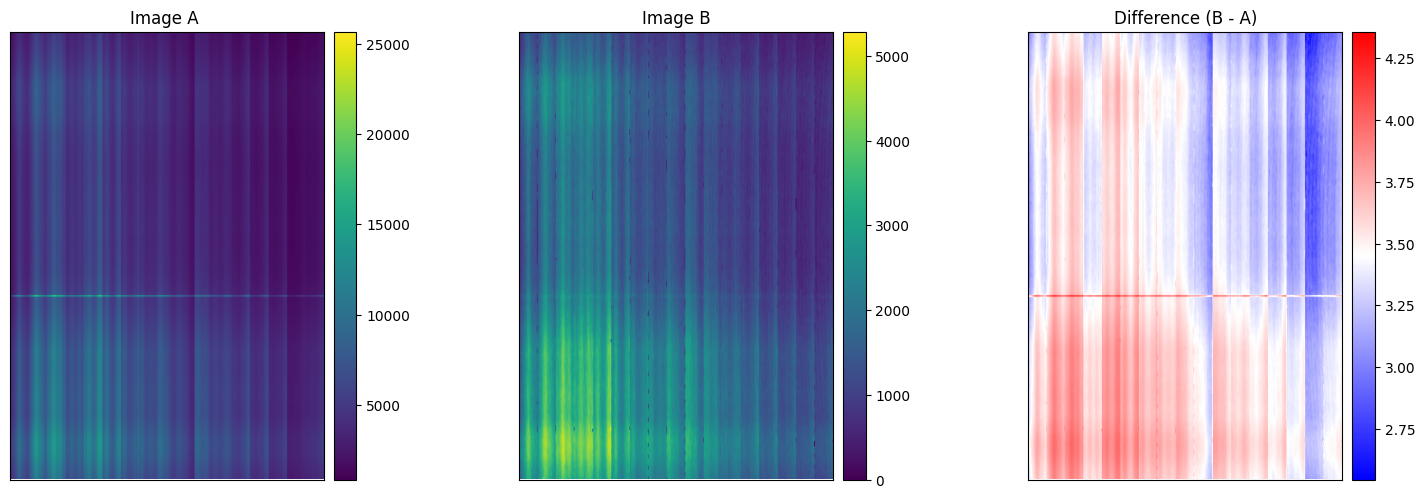

In [ ]:
paths, step_angle = model_creation.initialize_parameters(fusion_dir, step, True)

log.info('Load MRS data')
data_dict = model_creation.load_data(list_chan, paths["save_filter_corrected_dir"])

data = list()
for chan in list_chan:
    data.append(np.array(data_dict['data'][chan]).ravel())
ndata = np.concatenate(data)

# if scale_data:
#     log.info('Data scaling enable')
#     ndata = MRSModel.real_data_janskySR_to_jansky(ndata)

# corrected_data = MRSModel.real_data_janskySR_to_jansky(corrected_data)
list_corrected_data = MRSModel.get_list_of_data(corrected_data)

list_raw_data = MRSModel.get_list_of_data(ndata)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
imA = list_corrected_data[3][0]
imgA = imA.transpose(1, 0, 2).reshape(imA.shape[1], imA.shape[2]*imA.shape[0])

imB = list_raw_data[3][0]
imgB = imB.transpose(1, 0, 2).reshape(imB.shape[1], imB.shape[2]*imB.shape[0])

# --- Image A ---
im0 = axes[0].imshow(imgA, cmap="viridis", origin="lower")
axes[0].set_title(fr"Image A ", fontsize=12)
axes[0].set_xticks([]); axes[0].set_yticks([])

# --- Image B ---
im1 = axes[1].imshow(imgB, cmap="viridis", origin="lower")
axes[1].set_title(fr"Image B", fontsize=12)
axes[1].set_xticks([]); axes[1].set_yticks([])

# --- Différence ---
diff_img = np.log10(np.abs(imgB - imgA))
im2 = axes[2].imshow(diff_img, cmap="bwr", origin="lower")
axes[2].set_title("Difference (B - A)", fontsize=12)
axes[2].set_xticks([]); axes[2].set_yticks([])

# --- Colorbars ---
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02)

plt.tight_layout()
plt.show()